In [ ]:
# importing libraries
import pandas as pd 
import numpy as np
import matplotlib
import sklearn
import csv
import missingno as msno

# DATA
data_path = r""

# establish df - and encoding measure
df = pd.read_csv(data_path, encoding='latin-1')

<Axes: >

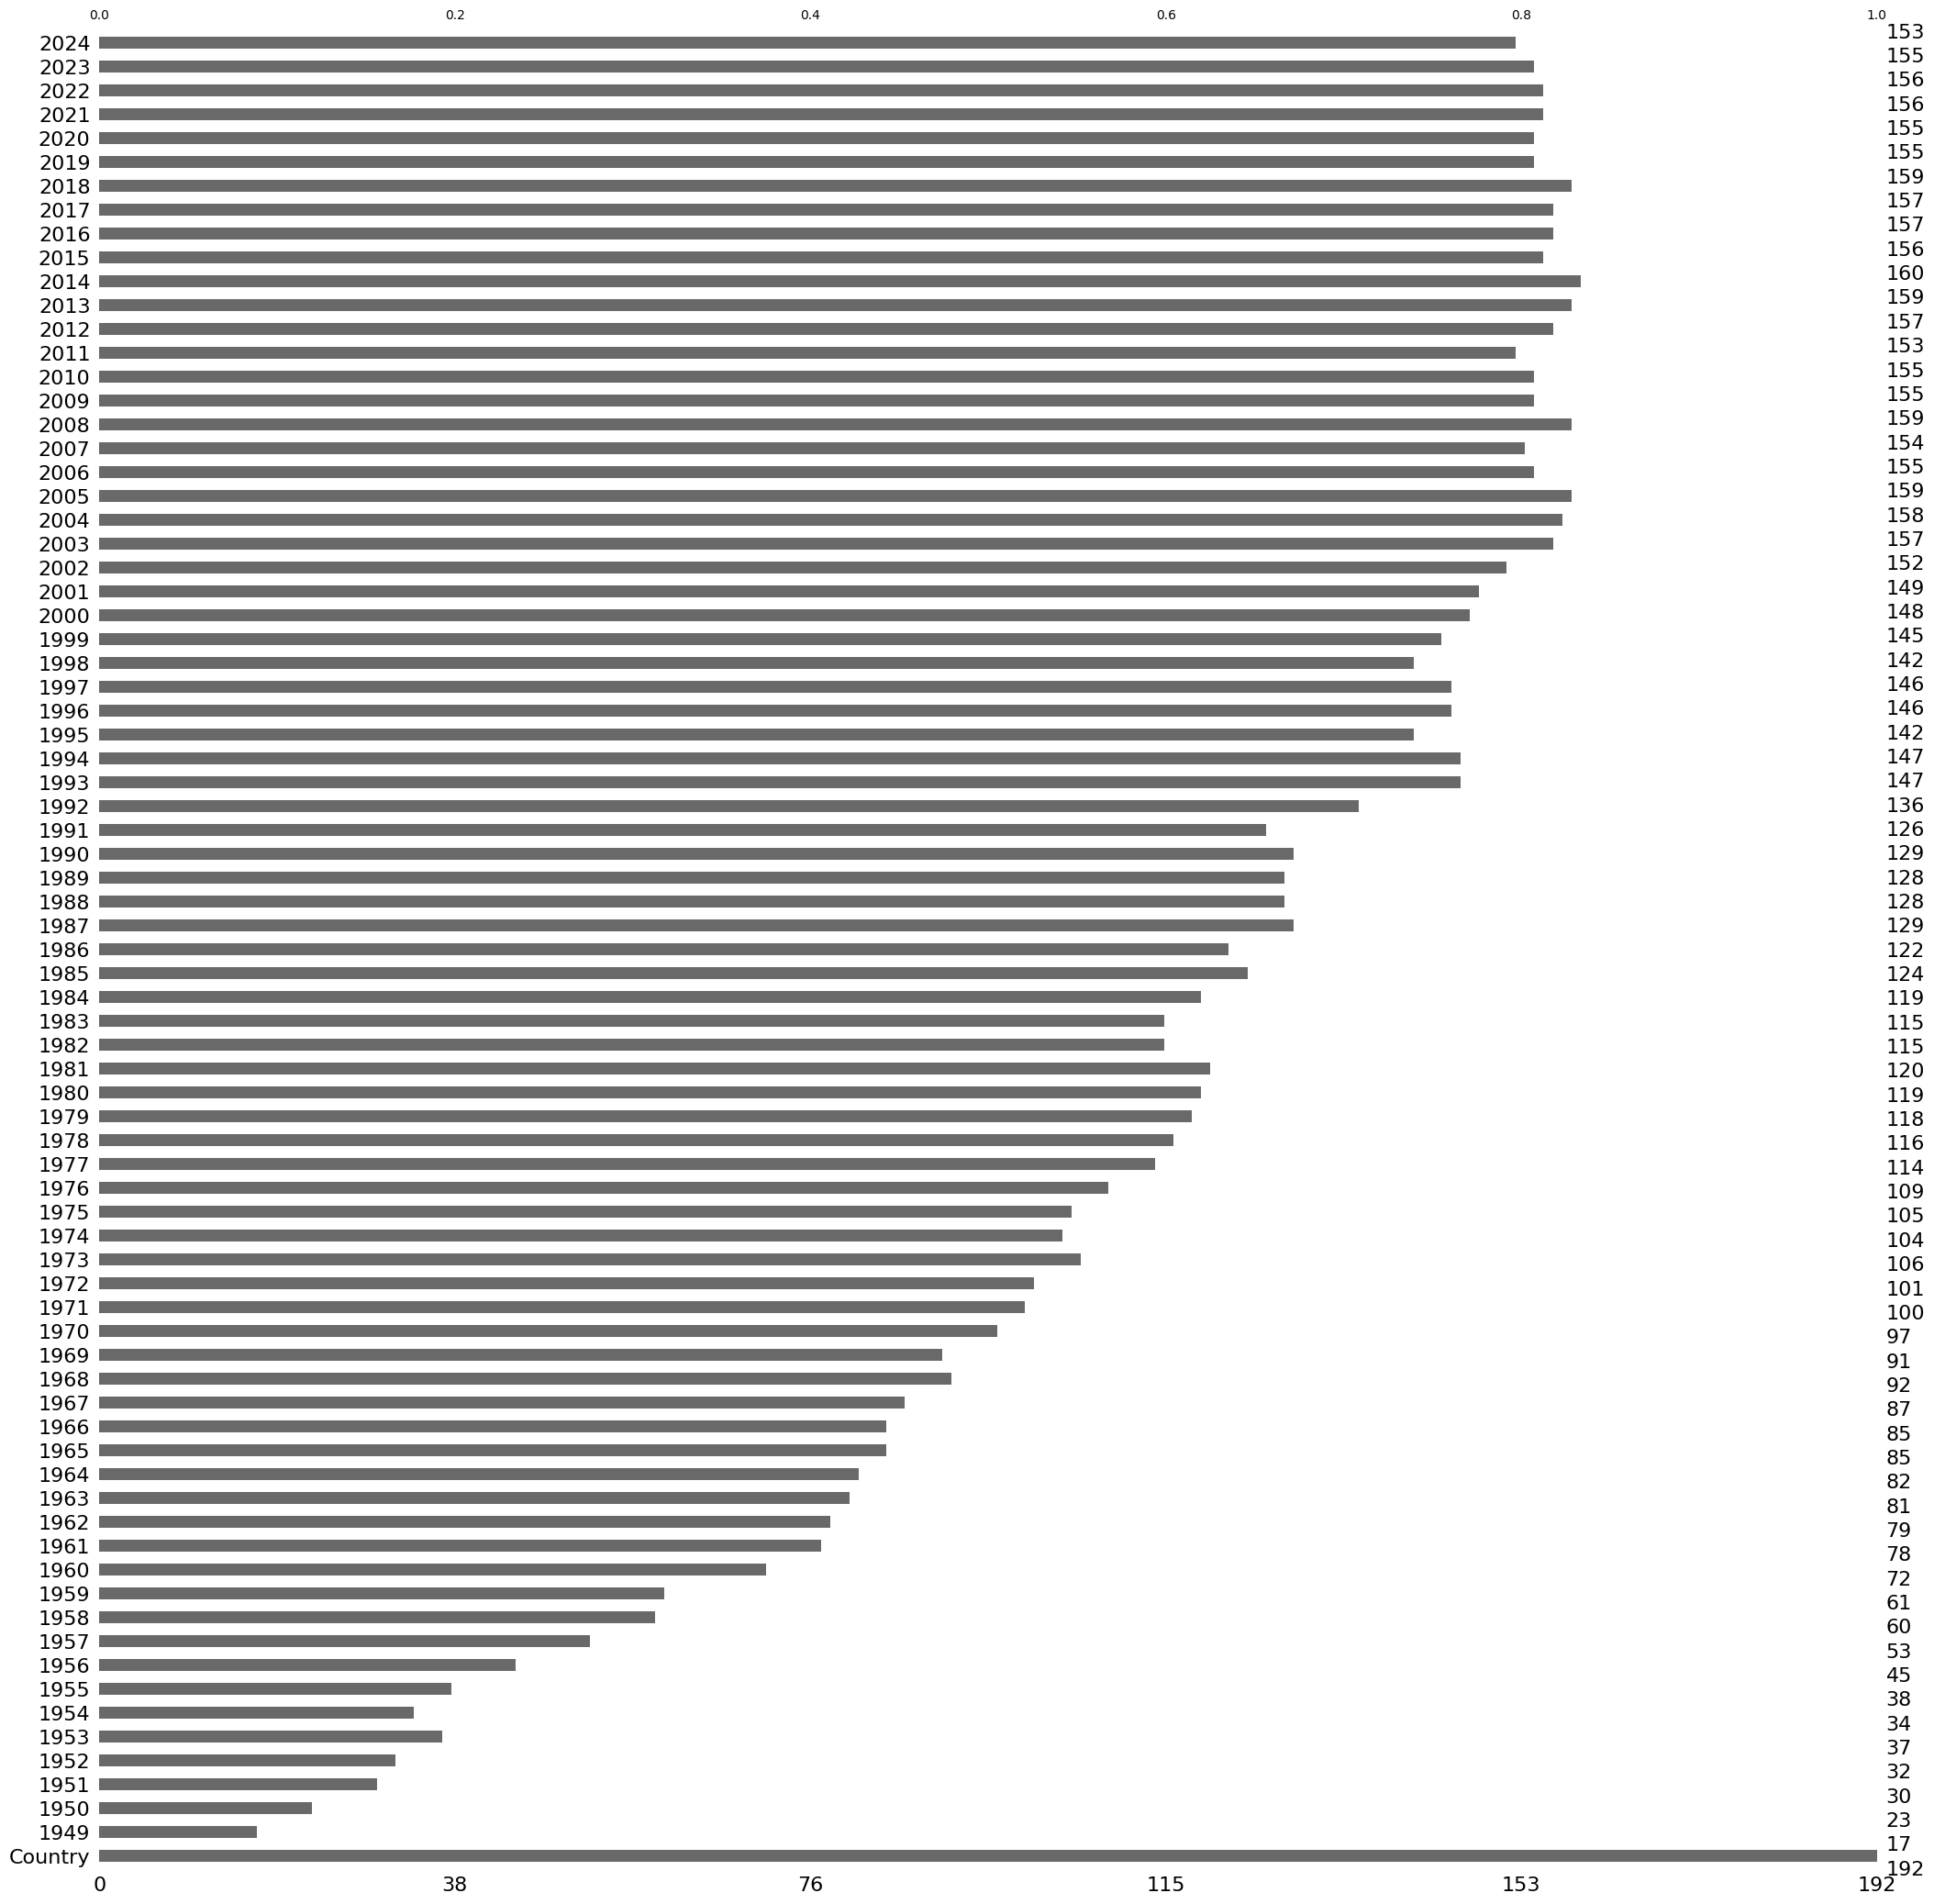

In [10]:
msno.bar(df)

In [11]:
# inspect and clean
df.head()


,Country,1949,1950,1951,1952,1953,1954,1955,1956,1957,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,North Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Algeria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10407.3,10217.1,10073.4,9583.7,10303.6,9708.3,9112.5,9145.8,18264.0,21811.2
3,Libya,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1214.9,1573.7,NaN
4,Morocco,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.7,35.4,...,3268.4,3327.0,3461.5,3696.9,3721.3,4831.0,5378.4,4995.0,5184.9,5517.9


In [18]:
pd.melt(df, id_vars=['Country'], value_vars=['1949', '1950', '1951', '1952', '1953', '1954', '1955',
       '1956', '1957', '1958', '1959', '1960', '1961', '1962', '1963', '1964',
       '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973',
       '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982',
       '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991',
       '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000',
       '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009',
       '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018',
       '2019', '2020', '2021', '2022', '2023', '2024'])

ValueError: value_name (value) cannot match an element in the DataFrame columns.

In [25]:
df.head()

,Country,Year,Spending
0,Costa Rica,1949,0.0
1,Mexico,1949,34.8
2,United States of America,1949,14088.2
3,Argentina,1949,0.0
4,Peru,1949,23.9


In [ ]:
#rename columns
df.columns = ['Country', 'Year', 'Spending']


# force the year numeric
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')


# drop missing 
df = df.dropna(subset=['Spending'])


# reset index 
df = df.reset_index(drop=True)

In [26]:
df.head()

,Country,Year,Spending
0,Costa Rica,1949,0.0
1,Mexico,1949,34.8
2,United States of America,1949,14088.2
3,Argentina,1949,0.0
4,Peru,1949,23.9


In [41]:
# Sort so lags are calculated in chronological order per country
df = df.sort_values(['Country', 'Year']).reset_index(drop=True)

# Create lag features within each country
df['Lag_1'] = df.groupby('Country')['Spending'].shift(1).dropna()
df['Lag_2'] = df.groupby('Country')['Spending'].shift(2).dropna()

# Add a year trend variable
df['Year_Trend'] = df['Year'] - df['Year'].min()

df.head(25)

,Country,Year,Spending,Lag_1,Lag_2,Year_Trend
0,Afghanistan,1970,2.9,NaN,NaN,21
1,Afghanistan,1973,3.3,2.9,NaN,24
2,Afghanistan,1974,3.6,3.3,2.9,25
3,Afghanistan,1975,4.2,3.6,3.3,26
4,Afghanistan,1976,5.4,4.2,3.6,27
5,Afghanistan,1977,6.1,5.4,4.2,28
6,Afghanistan,2004,125.1,6.1,5.4,55
7,Afghanistan,2005,122.7,125.1,6.1,56
8,Afghanistan,2006,131.3,122.7,125.1,57
9,Afghanistan,2007,219.6,131.3,122.7,58


In [ ]:
# grabbing training data 
df_model = df.copy()

# explicity drop missing values before splitting (handling edge cases &  lags)
df_model = df_model.dropna(subset=['Lag_1', 'Lag_2', 'Year_Trend', 'Spending']).reset_index(drop=True)


      Lag_1  Lag_2  Year_Trend
0      True   True       False
1     False   True       False
2     False  False       False
3     False  False       False
4     False  False       False
...     ...    ...         ...
8835  False  False       False
8836  False  False       False
8837  False  False       False
8838  False  False       False
8839  False  False       False

[7916 rows x 3 columns]


AttributeError: 'NoneType' object has no attribute 'sum'

In [50]:
train = df_model[df_model['Year'] <= 2018] #0.359375

# grabbing testing data 
test  = df_model[df_model['Year'] > 2018] #64%

# splitting the training columns 
X_train = train[['Lag_1', 'Lag_2', 'Year_Trend']] # independent variables (things that don't change)
y_train = train['Spending'] # dependent varibale (thing we change)

# splitting the test columns 
X_test = test[['Lag_1', 'Lag_2', 'Year_Trend']] #same as above
y_test = test['Spending'] #same as above

# show 
print(train.shape, test.shape)

(7570, 6) (928, 6)


In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor 

# Linear Regression - the baseline:
lr = LinearRegression()
lr.fit(X_train, y_train)

# gradient boosting - the challenger 
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr.fit(X_train, y_train)

print("complete")

complete


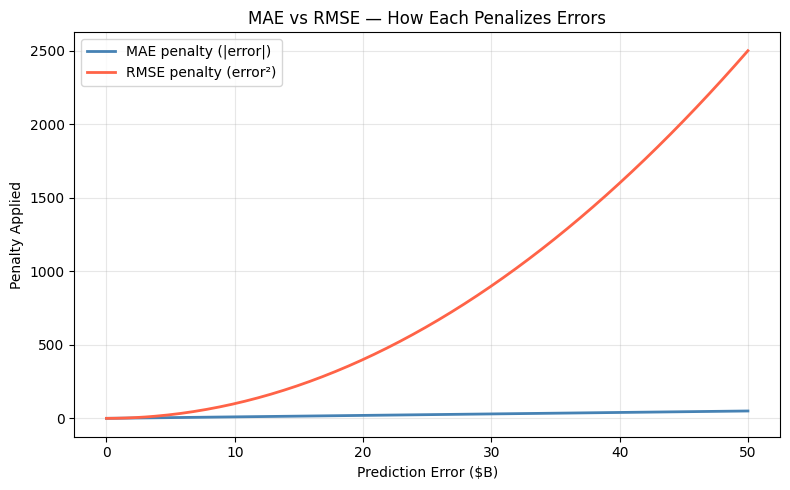

In [ ]:
# graphing the how errors function 

errors = np.linspace(0, 50, 200)  # error range in $B

mae_penalty  = errors                # linear — every error counts equally
rmse_penalty = errors ** 2           # squared — large errors explode

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(errors, mae_penalty,  label='MAE penalty (|error|)',    color='steelblue', linewidth=2)
ax.plot(errors, rmse_penalty, label='RMSE penalty (error²)',    color='tomato',    linewidth=2)

ax.set_xlabel('Prediction Error ($B)')
ax.set_ylabel('Penalty Applied')
ax.set_title('MAE vs RMSE — How Each Penalizes Errors')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# make preductions - call the results 
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

lr_preds = lr.predict(X_test)
gbr_preds = gbr.predict(X_test)

# metrics
def evaluate(name, preds, y_true):
    rmse = np.sqrt(root_mean_squared_error(y_true, preds))
    mae = mean_absolute_error(y_true, preds)
    r2 = r2_score(y_true, preds)
    print(f"{name}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  R²:   {r2:.4f}") #not sure what these ":.4f" syntax refers to. 
print()

evaluate("Linear Regression", lr_preds, y_test)
evaluate("Gradient Boosting", gbr_preds, y_test)

'''
# INTERPRETATION OF RESULTS:
- My MAE of (x)  means that on average, my predictions are off by (x) million dollars."
'''


Linear Regression
  RMSE: 58.21
  MAE:  944.02
  R²:   0.9978
Gradient Boosting
  RMSE: 113.97
  MAE:  1,817.12
  R²:   0.9683


In [ ]:
# checking data integrity:
df_model['Country'].unique()

<StringArray>
[             'Afghanistan',                  'Albania',
                  'Algeria',                   'Angola',
                'Argentina',                  'Armenia',
                'Australia',                  'Austria',
               'Azerbaijan',                  'Bahrain',
 ...
 'United States of America',                  'Uruguay',
               'Uzbekistan',                'Venezuela',
                 'Viet Nam',                    'Yemen',
             'Yemen, North',               'Yugoslavia',
                   'Zambia',                 'Zimbabwe']
Length: 174, dtype: str

In [ ]:
regional = ['Africa', 'North Africa', 'Sub-Saharan Africa', 'Americas', 
            'North America', 'Central America', 'South America', 
            'Europe', 'Western Europe', 'Eastern Europe', 'Central Europe',
            'Asia & Oceania', 'South Asia', 'East Asia', 'Middle East', 'World']

df_model = df_model[~df_model['Country'].isin(regional)]

In [ ]:
df_model['Country'].unique()
#length is the same 174 

<StringArray>
[             'Afghanistan',                  'Albania',
                  'Algeria',                   'Angola',
                'Argentina',                  'Armenia',
                'Australia',                  'Austria',
               'Azerbaijan',                  'Bahrain',
 ...
 'United States of America',                  'Uruguay',
               'Uzbekistan',                'Venezuela',
                 'Viet Nam',                    'Yemen',
             'Yemen, North',               'Yugoslavia',
                   'Zambia',                 'Zimbabwe']
Length: 174, dtype: str

AttributeError: module 'matplotlib.pyplot' has no attribute 'subtitle'

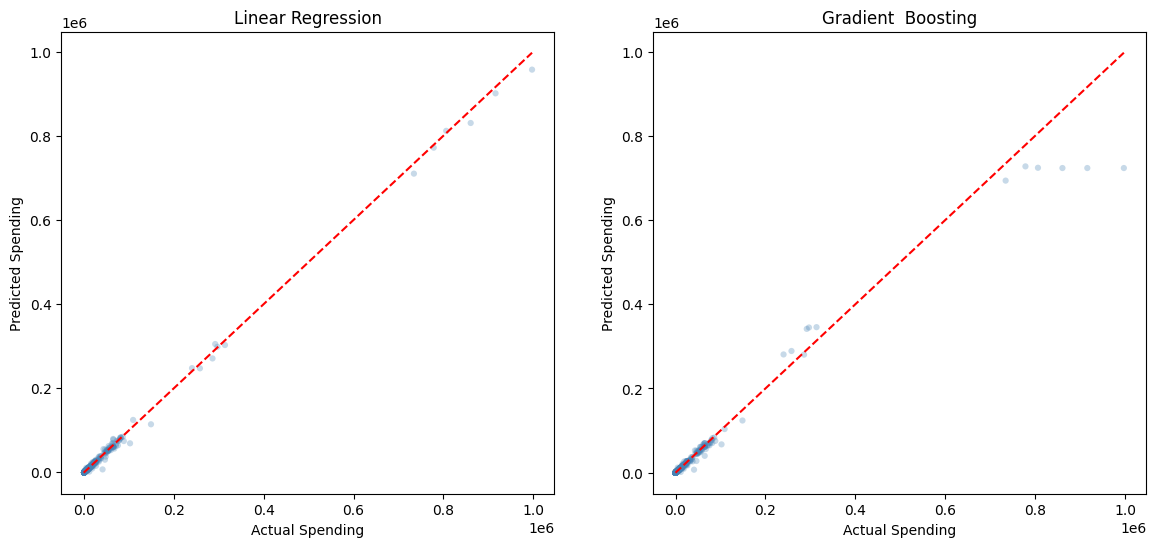

In [87]:

#Linear Regression
fig, axes = plt.subplots(1, 2, figsize = (14, 6))

models = [
    ("Linear Regression", lr_preds),
    ("Gradient  Boosting", gbr_preds)
]

for ax, (name, preds) in zip(axes, models):
    ax.scatter(y_test, preds, alpha = 0.3, edgecolors='none', color='steelblue', s=20)

    # diagonal reference line - perfect predictions sit on this:
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label = 'Perfect Prediciton')

    ax.set_xlabel('Actual Spending')
    ax.set_ylabel('Predicted Spending')
    ax.set_title(f'{name}')
    ax.legend

plt.subtitle('Actual vs. Predicted Military Expenditure', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Step 7 — Interpretation

### What did we find?

Two models were trained to forecast military expenditure using lag features 
(prior year and two-year prior spending) and a year trend variable across 
174 countries from the SIPRI dataset.

**Linear Regression outperformed Gradient Boosting on every metric:**

| Metric | Linear Regression | Gradient Boosting |
|--------|------------------|-------------------|
| RMSE   | 58.21            | 113.97            |
| MAE    | 944.02           | 1,817.12          |
| R²     | 0.9978           | 0.9683            |

### What does each metric tell us?

**RMSE:** Linear Regression's score of 58.21 vs GBR's 113.97 indicates LR 
produced fewer catastrophic misses. Large prediction errors are penalized 
disproportionately by RMSE — a single $100B miss costs far more than one 
hundred $1B misses. LR handled high-spending outlier countries more reliably.

**MAE:** On average, Linear Regression predictions were off by ~$944M per 
country-year observation. GBR averaged ~$1.8B per observation. MAE treats 
all errors equally regardless of magnitude — LR's lower score reflects 
consistently tighter predictions across the full dataset.

**R²:** LR's 0.9978 means the model accounts for 99.78% of variance in 
defense spending. GBR accounts for 96.83%. Both are strong, but LR's 
near-perfect score reflects how linear the underlying relationship is.

### Why did Linear Regression win?

Defense spending is a highly persistent, linear time series — a country's 
spending this year is a strong linear predictor of next year's spending. 
GBR's additional complexity found no nonlinearity to exploit.

GBR also suffered extrapolation failure at the high end. Decision trees 
can only predict values within the range of training observations — they 
have no mechanism to extend beyond their learned ceiling. Countries whose 
spending grew past 2018 training levels (USA, China) exposed this limitation 
directly, visible in the scatter plot as a flat cluster of predictions 
plateauing while actual spending continued to rise.

### Data quality caveat

A portion of SIPRI observations are flagged as estimated (blue) or highly 
uncertain (red). This affects confidence in predictions for smaller or 
conflict-affected countries where data quality is lowest.

### What would I tell a budget planning team?

"A linear model using prior year spending as the primary feature explains 
99.78% of variance in military expenditure across 174 countries. The model 
averages under $1B in prediction error — reasonable for strategic planning 
purposes. However, it should not be used to forecast spending for countries 
undergoing rapid budget growth, as the model's linearity assumption breaks 
down at inflection points. Gradient Boosting was evaluated as a challenger 
model but underperformed due to extrapolation limitations at the upper range 
of the spending distribution."

### Connection to thesis

The lag feature structure used here mirrors the Markov regression logic 
from the MS thesis — prior state predicts current state. The difference 
is domain: instead of predicting probabilistic state transitions, we are 
predicting a continuous budget value. The underlying assumption is the same.